## Fase 1 - EDA e Visualização dos dados

In [10]:
from sklearn.datasets import fetch_openml


print("Baixando o dataset...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

print("Finalizado")

Baixando o dataset...
Finalizado


In [11]:
#Primeiro pedido:
#SHAPE - imprimir quantidade de linhas e colunas

X = mnist.data #simplificando a vida
y = mnist.target #simplificando a vida

print(f"Qtde. de linhas = ", X.shape[0])
print(f"Qtde. de colunas = ", X.shape[1])
print(f"Qtde. de elementos =", y.shape[0])

Qtde. de linhas =  70000
Qtde. de colunas =  784
Qtde. de elementos = 70000


In [12]:
#Segundo pedido:
#Quantos exemplos existem e mostrar a distribuição

import numpy as np

digitos, quantidades = np.unique(y, return_counts=True)
#print(digitos) #teste

for digito, quantidade in zip(digitos, quantidades):
  print(f"Digito {digito}: {quantidade} exemplos")

#Meu TOC pede para organizar esses dados
#Quero mostrar o percentual dentro do total de exemplos
#Quero mostrar a mediana para vermos a distribuição | vejo uma curva interessante, por isso mediana
#Quero mostrar o delta entre maior e menor

print("----------------------------------------------------")

for digito, quantidade in zip(digitos, quantidades):
  percentual = ((quantidade / np.sum(quantidades))*100)
  print(f"Percentual de participação - Digito {digito}: {percentual:.2f}%")

print("----------------------------------------------------")
print("Mediana:", np.median(quantidades))
print("Delta:", np.max(quantidades) - np.min(quantidades))

Digito 0: 6903 exemplos
Digito 1: 7877 exemplos
Digito 2: 6990 exemplos
Digito 3: 7141 exemplos
Digito 4: 6824 exemplos
Digito 5: 6313 exemplos
Digito 6: 6876 exemplos
Digito 7: 7293 exemplos
Digito 8: 6825 exemplos
Digito 9: 6958 exemplos
----------------------------------------------------
Percentual de participação - Digito 0: 9.86%
Percentual de participação - Digito 1: 11.25%
Percentual de participação - Digito 2: 9.99%
Percentual de participação - Digito 3: 10.20%
Percentual de participação - Digito 4: 9.75%
Percentual de participação - Digito 5: 9.02%
Percentual de participação - Digito 6: 9.82%
Percentual de participação - Digito 7: 10.42%
Percentual de participação - Digito 8: 9.75%
Percentual de participação - Digito 9: 9.94%
----------------------------------------------------
Mediana: 6930.5
Delta: 1564


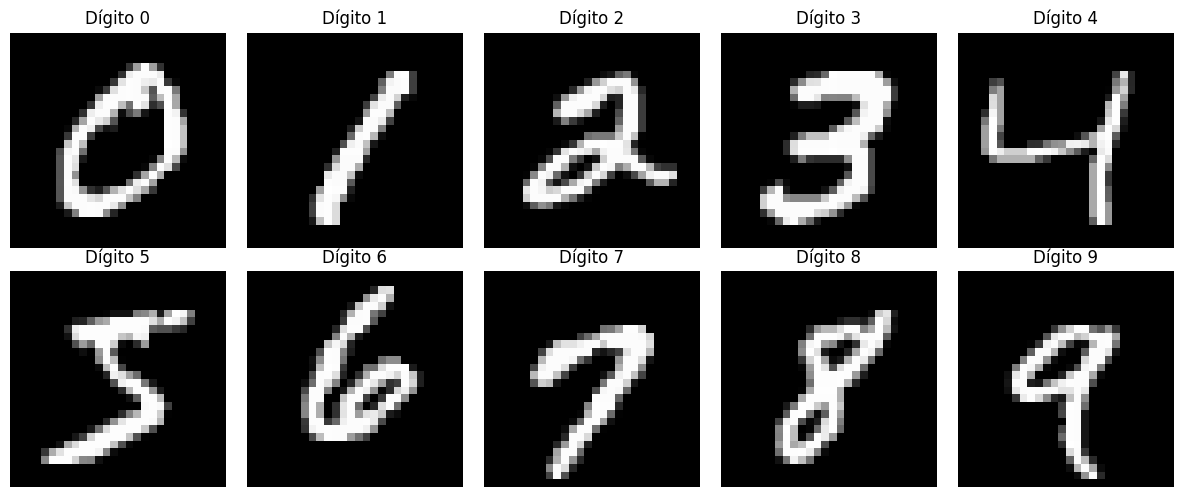

In [13]:
#Vamos criar uma grade de imagens com matplotlib
#reshape?

import matplotlib.pyplot as plt

fig, eixos = plt.subplots(nrows=2, ncols=5, figsize=(12,5))
eixos = eixos.flatten()

#achando o indice: np.where(y == 'digito')[0][0]
for digito, eixo in zip(digitos,eixos):
  indice = np.where(y == str(digito))[0][0]
  #print(indice) #teste
  X_reshaped = X[indice].reshape(28,28)
  eixo.imshow(X_reshaped, cmap='gray')
  eixo.set_title(f"Dígito {digito}")
  eixo.axis('off') #resolvi tirar as anotações do eixo, mais limpo

plt.tight_layout()
plt.show()


# **O que significa cada pixel valer de 0 a 255?**

Cada pixel usa 1 byte (8 bits) de memória, permitindo representar 256 (2^8) valores de intensidade de luz. Em outras palavras, no MNIST nós temos diferentes tons de cinza.

E em imagens em escala de cinza:
O valor 0 representa a ausência total de brilho (preto)
O valor 255 representa a intensidade máxima (branco)

Os números intermediários (1 a 254) representam os diferentes tons de cinza (usados para suavizar as bordas do traço).

# **Por que uma imagem 28x28 vira um vetor de 784 números?**

A imagem original é organizada como uma grade bidimensional (matriz tipo [n][k], onde n e k são numeros reais positivos) de 28 linhas e 28 colunas, totalizando 784 pixels.

Para alimentar modelos de aprendizado de máquina tradicionais e camadas densas de redes neurais, realizamos um processo chamado flattening (achatamento), empilhando todas as linhas em uma única fila unidimensional de 784 posições.

## Fase 2: Pipeline de pré-processamento e divisão dos dados

In [14]:
#Dividindo em treino, validação, testes (80/20). Escolhido 80/20 por uma questão de otimização de tempo pessoal até a entrega.
#Stratify=y para manter a proporção? test_size = 0.2

from sklearn.model_selection import train_test_split

dados_exemplo = X
rotulos_exemplo = y

X_treino, X_teste, y_treino, y_teste = train_test_split(
    dados_exemplo,
    rotulos_exemplo,
    test_size=0.2,
    stratify=rotulos_exemplo,
    random_state=42
)

#checagem de rotina
#print(f"X (x,y) = ", X_treino.shape)
#print(f"Y (elementos) =", y_treino.shape[0])
#estamos pegando 80% para treino, 20% para testes: legal okok


In [15]:
#Vamos normalizar os dados separados (avoid data leakage)
#Por que? Lembra do primeiro projeto?
#Algoritmos como KNN medem o quão longe uma coisa está da outra, com números inflados, corremos o risco de instabilidades e falta de sensibilidade às diferenças reais.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_treino_normalizado = scaler.fit_transform(X_treino)
X_teste_normalizado = scaler.transform(X_teste)

#Testes
#print(X_treino.min())
#print(X_treino.max())
#print(X_treino_normalizado.min())
#print(X_treino_normalizado.max())
#print(X_treino.shape)
#print(X_treino_normalizado.shape)
#Achando indice do treino normalizado com o y_treino, retorna imagens corretas, mesmos codigos acima
#good to go

# **Por que a normalização ajuda?**

Similarmente ao primeiro projeto, modelos que usam distância, quanto menor a distância entre os pontos (nesse caso, os pontos que formam a imgem) maior a precisão e sensibilidade do modelo. Por isso reduzimos de 0 a 255 para 0.0 a 1.0. A exemplo do professor: qual a precisão de um passo de 200 unidades de distância contra um de 1 unidade de distância?

Por isso normalizados, reduzindo a distância dos passos.

# **E para rede neural?**

Pesquisando encontrei que o motivo é similar. As entradas grandes tornam o treino instável e demorado. Com entradas menores tende a ser mais rápido e estável.

##Fase 3 - Implementação e treinamento dos 3 Modelos

In [16]:
#Combinação segura de modelos: KNN, Random Forest e MLP simples
#Para KNN, hipeparametro: n_neighbors, ou seja não deixar o KNeighhborsClassifier() em default
#Decidir nos números e justificar pro exercício
#Para Random Forest: n_estimators e max_depth, quantas arvores e qual a profundidade delas
#Para MLP simples, número de neuronios e taxa de aprendizado.

from sklearn.neighbors import KNeighborsClassifier
import time

#Parametros, em lista para fazer os testes com diferentes vizinhos para KNN
lista = [3,5,7]
for i in lista:
  N = i

  knn = KNeighborsClassifier(n_neighbors=N, weights='distance')

  #random_state serve para reproduzir a aleatoriedade de forma equivalente no futuro
  #A fase 4 pede comparativo, então vou marcar o delta tempo dos 3 modelos.


  #--------------KNN--------------
  print("-"*15, f"KNN = {N}", "-"*15)

  #FIT
  inicio = time.time()
  knn.fit(X_treino_normalizado, y_treino)
  tempo_treino_knn = time.time() - inicio
  print(f"Tempo de treino KNN: {tempo_treino_knn:.2f} segundos")

  #PREDICT
  inicio_predicao = time.time()
  knn_predicoes = knn.predict(X_teste_normalizado)
  tempo_predicao_knn = time.time() - inicio_predicao
  print(f"Tempo de predição KNN: {tempo_predicao_knn:.2f} segundos")

  #TOTAL
  tempo_total_knn = tempo_treino_knn + tempo_predicao_knn
  print(f"Tempo total KNN: {tempo_total_knn:.2f} segundos")

--------------- KNN = 3 ---------------
Tempo de treino KNN: 0.10 segundos
Tempo de predição KNN: 59.01 segundos
Tempo total KNN: 59.11 segundos
--------------- KNN = 5 ---------------
Tempo de treino KNN: 0.10 segundos
Tempo de predição KNN: 70.76 segundos
Tempo total KNN: 70.86 segundos
--------------- KNN = 7 ---------------
Tempo de treino KNN: 0.12 segundos
Tempo de predição KNN: 71.79 segundos
Tempo total KNN: 71.91 segundos


# Os três estavam em uma mesma célula, resolvi separar por performance do projeto.

In [17]:
from sklearn.ensemble import RandomForestClassifier
import time

#Parametros, em lista para fazer dois testes de estimativa
lista_rf = [50,100,200]

for k in lista_rf:
  N = k

  rf = RandomForestClassifier(n_estimators=N, max_depth=20, random_state=42)

  #--------------Random Forest--------------
  print("-"*15, f"Random Forest: n_estimators = {N}", "-"*15)
  #FIT
  inicio = time.time() #restart
  rf.fit(X_treino_normalizado, y_treino)
  tempo_treino_rf = time.time() - inicio
  print(f"Tempo de treino Random Forest: {tempo_treino_rf:.2f} segundos")

  #PREDICT
  inicio = time.time()
  rf_predicoes = rf.predict(X_teste_normalizado)
  tempo_predicao_rf = time.time() - inicio
  print(f"Tempo de predição Random Forest: {tempo_predicao_rf:.2f} segundos")

  #TOTAL
  tempo_total_rf = tempo_treino_rf + tempo_predicao_rf
  print(f"Tempo total Random Forest: {tempo_total_rf:.2f} segundos")

--------------- Random Forest: n_estimators = 50 ---------------
Tempo de treino Random Forest: 33.49 segundos
Tempo de predição Random Forest: 0.50 segundos
Tempo total Random Forest: 33.99 segundos
--------------- Random Forest: n_estimators = 100 ---------------
Tempo de treino Random Forest: 57.27 segundos
Tempo de predição Random Forest: 0.63 segundos
Tempo total Random Forest: 57.90 segundos
--------------- Random Forest: n_estimators = 200 ---------------
Tempo de treino Random Forest: 106.45 segundos
Tempo de predição Random Forest: 1.20 segundos
Tempo total Random Forest: 107.65 segundos


In [18]:
from sklearn.neural_network import MLPClassifier #utilizado por ser similar aos dois acima, economia de tempo para a entrega em 2 dias
import time

#Parametros
mlp = MLPClassifier(hidden_layer_sizes=(128,), learning_rate_init=0.001, max_iter=50, random_state=42)

#--------------MLP--------------
print("-"*15, "MLP", "-"*15)
#FIT
inicio = time.time() #restart
mlp.fit(X_treino_normalizado, y_treino)
tempo_treino_mlp = time.time() - inicio
print(f"Tempo de treino MLP: {tempo_treino_mlp:.2f} segundos")

#PREDICT
inicio = time.time()
mlp_predicoes = mlp.predict(X_teste_normalizado)
tempo_predicao_mlp = time.time() - inicio
print(f"Tempo de predição MLP: {tempo_predicao_mlp:.2f} segundos")

#TOTAL
tempo_total_mlp = tempo_treino_mlp + tempo_predicao_mlp
print(f"Tempo total MLP: {tempo_total_mlp:.2f} segundos")

--------------- MLP ---------------
Tempo de treino MLP: 140.20 segundos
Tempo de predição MLP: 0.16 segundos
Tempo total MLP: 140.36 segundos


Para o KNN, testamos n_neighbors em {3, 5, 7}, com tempo de execução praticamente insensível ao valor escolhido.

Para o Random Forest, testamos n_estimators em {50, 100, 200}, com tempo escalando quase linearmente com o número de árvores com o mesmo max_depth.

Para o MLP, os hiperparâmetros (128 neurônios, taxa de aprendizado 0.001) foram definidos por raciocínio técnico, dado o custo computacional mais alto de testar variações empiricamente dentro do prazo disponível. E devido ao longo tempo de processamento, não foi testado de outro modo.

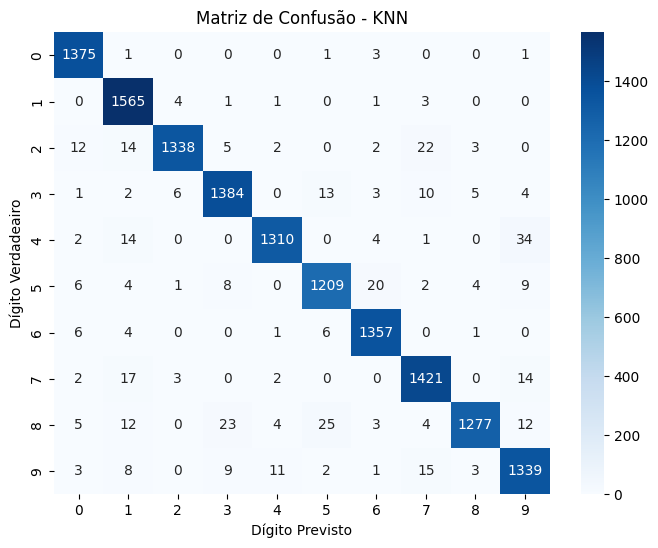

KNN - O dígito 4 foi mais confundido com o dígito 9, 34 vezes


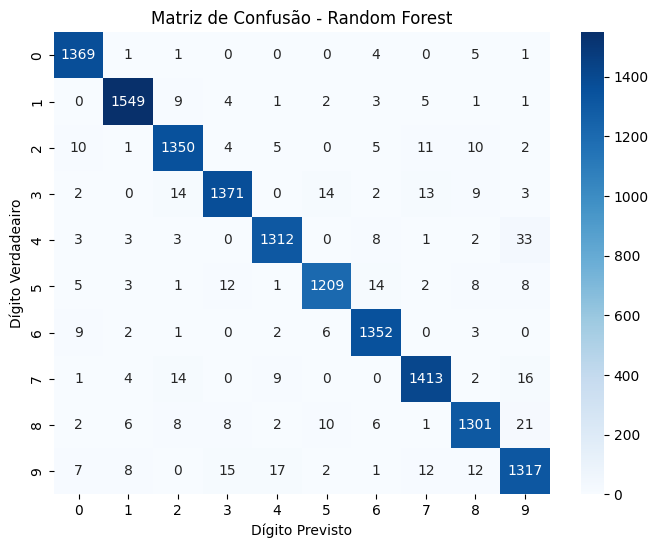

Random Forest - O dígito 4 foi mais confundido com o dígito 9, 33 vezes


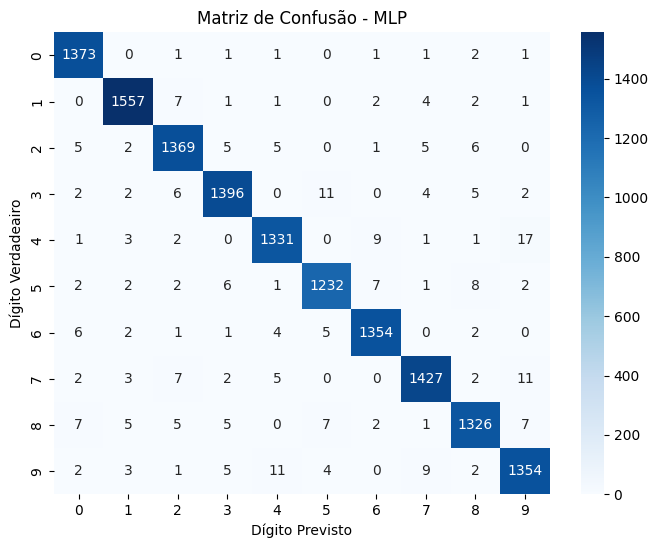

MLP - O dígito 4 foi mais confundido com o dígito 9, 17 vezes


In [21]:
#FASE 4 - Avaliação Comparativa de Desempenho
#Matriz de confusão 10x10 e heatmap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

modelos = ['KNN', 'Random Forest', 'MLP']
lista = [knn_predicoes, rf_predicoes, mlp_predicoes]

for nome, predicoes in zip(modelos, lista):
    matriz = confusion_matrix(y_teste, predicoes, labels=digitos)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=digitos, yticklabels=digitos)
    plt.xlabel('Dígito Previsto')
    plt.ylabel('Dígito Verdadeairo')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()

    matriz_sem_diagonal = matriz.copy()
    np.fill_diagonal(matriz_sem_diagonal, 0)
    linha, coluna = np.unravel_index(matriz_sem_diagonal.argmax(), matriz_sem_diagonal.shape)

    print(f"{nome} - O dígito {digitos[linha]} foi mais confundido com o dígito {digitos[coluna]}, {matriz_sem_diagonal[linha, coluna]} vezes")

In [22]:
#Calculando acurácia, precisão ponderada, recall ponderado e F1 ponderado

#Acurácia: Quantas previsões o modelo acertou
#Precisão: Quantas vezes o digito era de fato o digito
#Recall: De todos os digitos, quantos o modelo encontrou
#F1: Média entre precisão e recall, útil para imparcialidade


from sklearn.metrics import classification_report, accuracy_score

relatorio_knn = classification_report(y_teste, knn_predicoes, output_dict=True)
acuracia_knn = accuracy_score(y_teste, knn_predicoes)
precisao_knn = relatorio_knn['weighted avg']['precision']
recall_knn = relatorio_knn['weighted avg']['recall']
f1_knn = relatorio_knn['weighted avg']['f1-score']

print("-"*15, "KNN", "-"*15)
print(f"Acurácia: {acuracia_knn:.2f}")
print(f"Precisão: {precisao_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1: {f1_knn:.2f}")

relatorio_rf = classification_report(y_teste, rf_predicoes, output_dict=True)
acuracia_rf = accuracy_score(y_teste, rf_predicoes)
precisao_rf = relatorio_rf['weighted avg']['precision']
recall_rf = relatorio_rf['weighted avg']['recall']
f1_rf = relatorio_rf['weighted avg']['f1-score']

print("-"*15, "Random Forest", "-"*15)
print(f"Acurácia: {acuracia_rf:.2f}")
print(f"Precisão: {precisao_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1: {f1_rf:.2f}")

relatorio_mlp = classification_report(y_teste, mlp_predicoes, output_dict=True)
acuracia_mlp = accuracy_score(y_teste, mlp_predicoes)
precisao_mlp = relatorio_mlp['weighted avg']['precision']
recall_mlp = relatorio_mlp['weighted avg']['recall']
f1_mlp = relatorio_mlp['weighted avg']['f1-score']

print("-"*15, "MLP", "-"*15)
print(f"Acurácia: {acuracia_mlp:.2f}")
print(f"Precisão: {precisao_mlp:.2f}")
print(f"Recall: {recall_mlp:.2f}")
print(f"F1: {f1_mlp:.2f}")

--------------- KNN ---------------
Acurácia: 0.97
Precisão: 0.97
Recall: 0.97
F1: 0.97
--------------- Random Forest ---------------
Acurácia: 0.97
Precisão: 0.97
Recall: 0.97
F1: 0.97
--------------- MLP ---------------
Acurácia: 0.98
Precisão: 0.98
Recall: 0.98
F1: 0.98


# **Tabela comparativa dos modelos:**

Para KNN, usamos KNN = 5 já que não pareceu interferir tanto no resultado e para Random Forest, mantivemos também, o intermediário que equilibra custo benefício.

| Modelo | Hiperparâmetros ajustados | Tempo de Treino (s) | Tempo de Predição (s) | Tempo Total (s) | Acurácia | Precisão (ponderada) | Recall (ponderado) | F1 (ponderado) |
|---|---|---|---|---|---|---|---|---|
| KNN | n_neighbors=5, weights='distance' | 0.29 | 50.02 | 50.31 | 0.97 | 0.97 | 0.97 | 0.97 |
| Random Forest | n_estimators=100, max_depth=20 | 47.76 | 0.57 | 48.33 | 0.97 | 0.97 | 0.97 | 0.97 |
| MLP | hidden_layer_sizes=(128,), learning_rate_init=0.001 | 125.13 | 0.17 | 125.30 | 0.98 | 0.98 | 0.98 | 0.98 |

</br>

**Notas:**
</br>

O **KNN** faz o fit quase instantaneamente enquanto leva um tempo de processamento real mais alto. Pesquisando, vejo que faz sentido, uma vez que o fit serve para memorizar dados e é no .predict() que o trabalho acontece de verdade.
</br>

No **Random Forest**, vemos que ele faz um processamento longo no fit, que relaciona com a criação de 100 árvores e economiza muito no .predict(), pois as árvores estão prontas e só precisa percorrer a estrutura para chegar na resposta.
</br>

No **MLP**, tem um tempo de treino bem grande, enquanto o .predict() fica bastante rápido. O que também faz sentido, o treino envolve repetir o ajuste de pesos por várias iterações (até 50 aqui) enquanto a predição usa os pesos prontos numa única vez por entrada.

</br></br>

**Com acurácia e F1 similares nos 3 modelos, olhamos para o tempo.**</br>
O custo do Random Forest e do MLP está no treino, que acontece uma única vez. Enquanto o custo do KNN está vinculado ao .predict(), que se repete a cada nova predição. Com previsões frequentes, o KNN pode parecer mais barato, em um primeiro momento, mas acabar custando mais caro no longo-prazo. **Aqui, eliminamos a recomendação do KNN.** </br>

Considerando o cenário atual, com volume de predições em 14 mil e havendo uma abixa diferença na confusão entre os dois modelos promovidos, o Random Forest vence no tempo total, porque sua vantagem no treino é grande suficiente para compensar seu maior custo de predição frente ao MLP. Se o volume de predições crescesse muito, isso poderia se inverter.

**Recomendado: Random Forest**

In [23]:
#FASE 5
#1 - Desafio A: Treinamento com classes ocultas
#Escolher os digitos 4 e 7 para remover
#Filtrar o conjunto de treino removendo todas as linhas onde y é 4 ou 7
#Treinar um dos modelos só com os 8 dígitos restantes
#Modelo escolhido, devido ao concluído na fase anterior: Random Forest


mask = ~np.isin(y_treino, ['4','7']) #usamos 4 e 7 por alguns motivos: é do enunciado e o 4 é um número bastante confundido.

X_treino_oculto = X_treino_normalizado[mask]
y_treino_oculto = y_treino[mask]

#print(np.unique(y_treino_oculto)) #teste, ok

rf_mask = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_mask.fit(X_treino_oculto, y_treino_oculto)

RandomForestClassifier(max_depth=20, random_state=42)

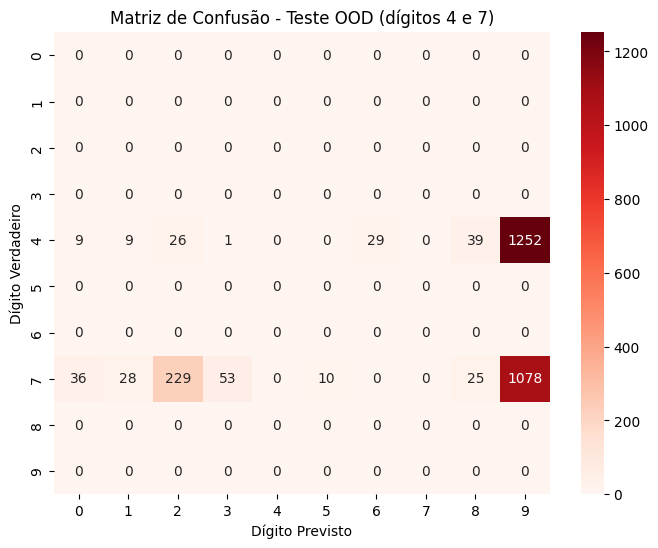


Confiança média das previsões: 57.68%


In [24]:
#FASE 5
#2 - Desafio B Teste de Generalização Extrema (OOD)
#Montar um conjunto de teste só com imagens dos dígitos ocultados (4 e 7)
#Rodar o modelo do desafio A nesse conjunto e ve quais classes conhecidas ele escolhe para esses digitos
# Plotar a matriz de confusão desse teste, vai ficar "torta" (?)
#Escrever minhas impressões

mask_ood = np.isin(y_teste, ['4', '7'])

X_teste_ood = X_teste_normalizado[mask_ood]
y_teste_ood = y_teste[mask_ood]

predict_ood = rf_mask.predict(X_teste_ood)

matriz_ood = confusion_matrix(y_teste_ood, predict_ood, labels=digitos)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_ood, annot=True, fmt='d', cmap='Reds', xticklabels=digitos, yticklabels=digitos)
plt.xlabel('Dígito Previsto')
plt.ylabel('Dígito Verdadeiro')
plt.title('Matriz de Confusão - Teste OOD (dígitos 4 e 7)')
plt.show()


#Pesquisando recebi uma dica interessante: testa o quão confiante o modelo estava mesmo errando. Segue:

proba_ood = rf_mask.predict_proba(X_teste_ood)
avg_trust = proba_ood.max(axis=1).mean()
print(f"\nConfiança média das previsões: {avg_trust:.2%}")

# **Impressões:**

É interessante ver que o modelo não se recusa a responder, mas busca uma similaridade entre a informação que está disponível.

De certo modo, geometricamente, o 4 se assemelha ao 9, sendo uma espécie de versão em linha reta do número 9, que pode justificar os mais de 90% de confusão. Bem como o 7, que também parece ser uma versão em linha reta do número 2 e do número 9, justificando a incidência de confusão com esses dois, sendo 73,9% classificado como 9 e 15,7% como 2.

Após ler a dica de rodarmos um teste de overconfidence, vimos 57,68% de confiança, o que indica uma discrepância, afinal, o modelo deveria chutar próximo de 12,5% entre as 8 classes remanescentes, mas tem bem mais confiança do que isso numa resposta errada. Se comportando como se soubesse a resposta, o impacto negativo de algo assim, sem supervisão, pode ser abismal.

In [25]:
#FASE 5.3 - Handwriting
#Desenhar uns números, adequar formato, subir pro colab, evitar apontar pro meu computador.
#Desenhei no photopea ja com fundo preto e letra branca, vamos ver...

from google.colab import files
from PIL import Image

enviados = files.upload()

imagens_proc = {}

for nome_arquivo in enviados.keys():
  imagem = Image.open(nome_arquivo).convert('L')
  imagens_proc[nome_arquivo] = imagem


Saving e-numero.png to e-numero (4).png
Saving d-numero.png to d-numero (4).png
Saving c-numero.png to c-numero (4).png
Saving b-numero.png to b-numero (4).png
Saving a-numero.png to a-numero (4).png


In [33]:
#Apesar de criar as imagens já com os requisitos de centralização e tamanho, notei que esses códigos compõem a nota final, então trago aqui:
#Depois normalizo

def centralizar_bounding_box(array_imagem):
    linhas = np.any(array_imagem > 0, axis=1)
    colunas = np.any(array_imagem > 0, axis=0)
    linha_min, linha_max = np.where(linhas)[0][[0, -1]]
    coluna_min, coluna_max = np.where(colunas)[0][[0, -1]]

    digito_cortado = array_imagem[linha_min:linha_max+1, coluna_min:coluna_max+1]

    canvas = np.zeros((28, 28))
    altura, largura = digito_cortado.shape
    y_inicio = (28 - altura) // 2
    x_inicio = (28 - largura) // 2
    canvas[y_inicio:y_inicio+altura, x_inicio:x_inicio+largura] = digito_cortado

    return canvas



In [37]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42) #redefinindo o estimators como 100 como mencionado acima
rf.fit(X_treino, y_treino) #erro que precisaria rodar o fit antes

resultados = {}
imagens_centralizadas = {}

for nome_arquivo, imagem in imagens_proc.items():
  array_imagem = np.array(imagem)
  array_centralizado = centralizar_bounding_box(array_imagem)
  imagens_centralizadas[nome_arquivo] = array_centralizado

  array_normalizado = array_centralizado / 255.0
  array_reshape = array_normalizado.reshape(1, -1)

  predicao = rf.predict(array_reshape)
  probs = rf.predict_proba(array_reshape)

  resultados[nome_arquivo] = (predicao[0], probs[0])

  print(f"{nome_arquivo}: previsto como {predicao[0]}")

e-numero (4).png: previsto como 7
d-numero (4).png: previsto como 5
c-numero (4).png: previsto como 7
b-numero (4).png: previsto como 7
a-numero (4).png: previsto como 7


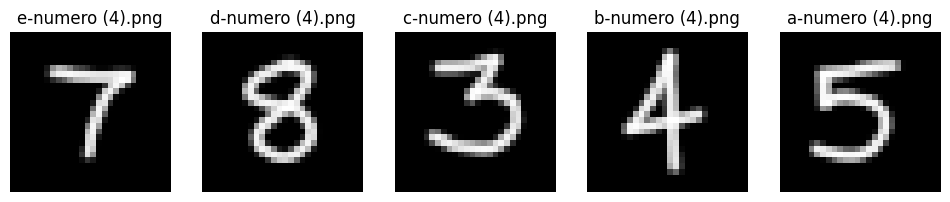

e-numero (4).png: previsto 7 com 34.52% de confiança
d-numero (4).png: previsto 5 com 21.99% de confiança
c-numero (4).png: previsto 7 com 25.58% de confiança
b-numero (4).png: previsto 7 com 24.29% de confiança
a-numero (4).png: previsto 7 com 26.40% de confiança


In [38]:
#Com resultado acima não muito satisfatório, resolvi checar as imagens do que fiz
#Parecem condizentes com o que testamos anteriormente
#Problema de generalização?
#Testar confiança com o código que já fizemos

fig, eixos = plt.subplots(nrows=1, ncols=5, figsize=(12, 3))
for eixo, (nome, imagem) in zip(eixos, imagens_proc.items()):
    eixo.imshow(imagem, cmap='gray')
    eixo.set_title(nome)
    eixo.axis('off')
plt.show()

for nome, (predicao, probs) in resultados.items():
    confianca = probs.max() * 100
    print(f"{nome}: previsto {predicao} com {confianca:.2f}% de confiança")

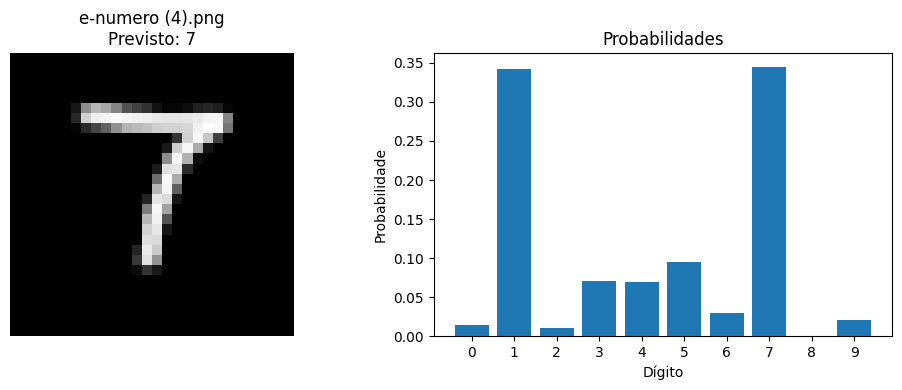

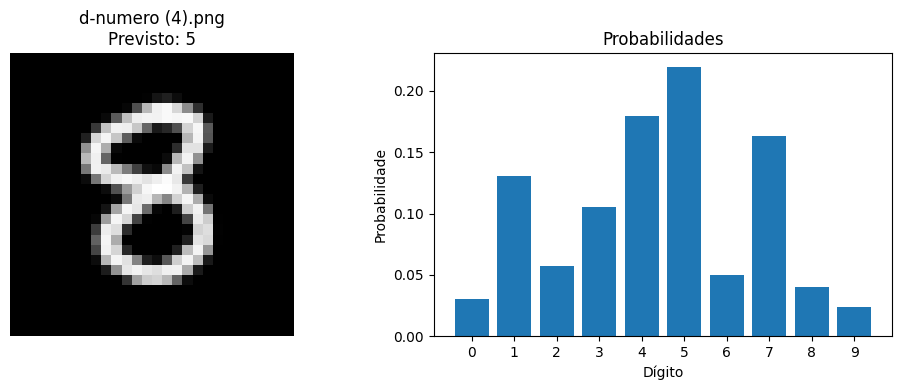

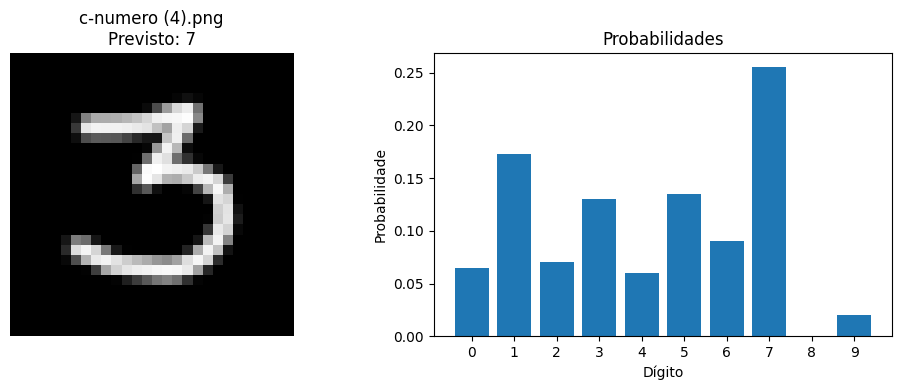

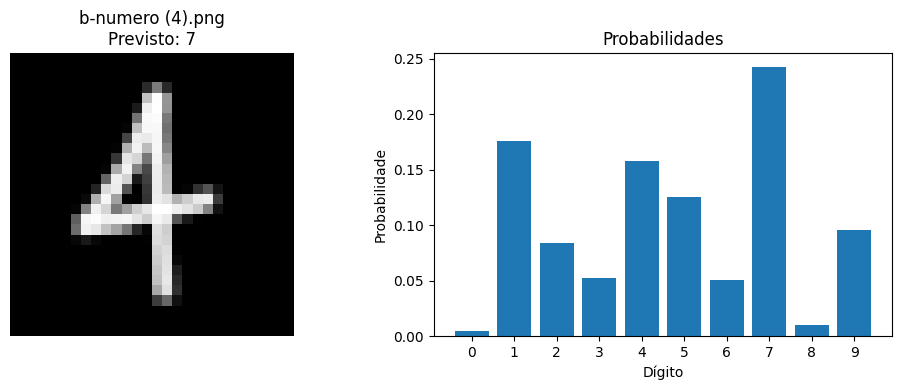

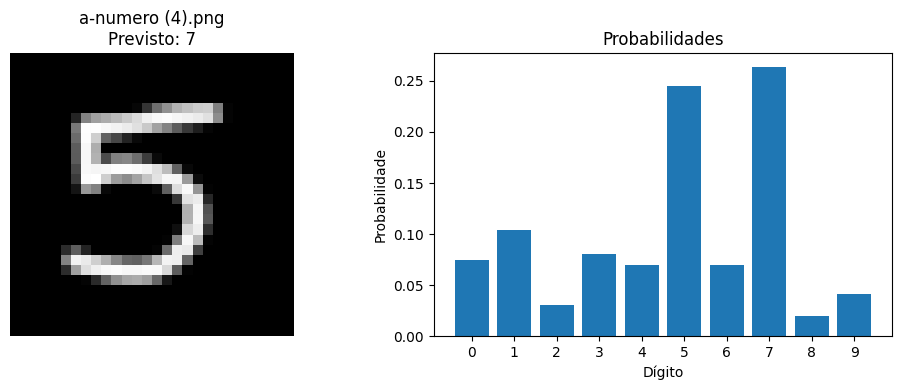

In [39]:
for nome, imagem in imagens_centralizadas.items():
    predicao, probs = resultados[nome]

    fig, (eixo_img, eixo_graf) = plt.subplots(1, 2, figsize=(10, 4))

    eixo_img.imshow(imagem, cmap='gray')
    eixo_img.set_title(f"{nome}\nPrevisto: {predicao}")
    eixo_img.axis('off')

    eixo_graf.bar(digitos, probs)
    eixo_graf.set_xlabel('Dígito')
    eixo_graf.set_ylabel('Probabilidade')
    eixo_graf.set_title('Probabilidades')

    plt.tight_layout()
    plt.show()

# **Conclusão:**

Em um primeiro momento, confesso que foi um susto ver que os números estavam todos indo para o "7".

Então fui comparar o padrão de imagens e depois a confiança e percebi que o modelo está com o comportamento adequado, com essa confiança, ele diz que está em dúvida do que está acontecendo e dividindo a probabilidade.


Aqui, diferente de antes, ele erra com dúvida e não com certeza como quando tiramos dois comparativos.

Posteriormente, rodando uma IA para fazer QA do ambiente, percebi que estava puxando os números crus, não a imagem processada após centralização. Interessante notar que o número acertado, foi o únco alterado, onde a confiança do programa diminuiu cerca de 10 p.p em relação a antes da centralização. Mostrando a sensibilidade do modelo.